# Customer Churn Prediction – Telco Dataset

**Task:** This notebook was written by a junior analyst. It runs without errors, but it contains **several mistakes** in data handling, modelling, evaluation and interpretation.

Your job:
1. Read and run the notebook.
2. Find every mistake you can. For each one, write: **the cell**, **what is wrong**, **why it matters**, and **how to fix it**.
3. Produce a corrected version of the notebook and compare the results.

Submit your findings as a Word document plus the corrected notebook.

## 1. Load the data

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Cleaning
`TotalCharges` is stored as text, so we convert it to a number.

In [47]:
#first change
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0 # add to ythe code to fill the missing valus
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median()) #change mean to median
df.isnull().sum().sum()

np.int64(0)

## 3. Exploratory analysis

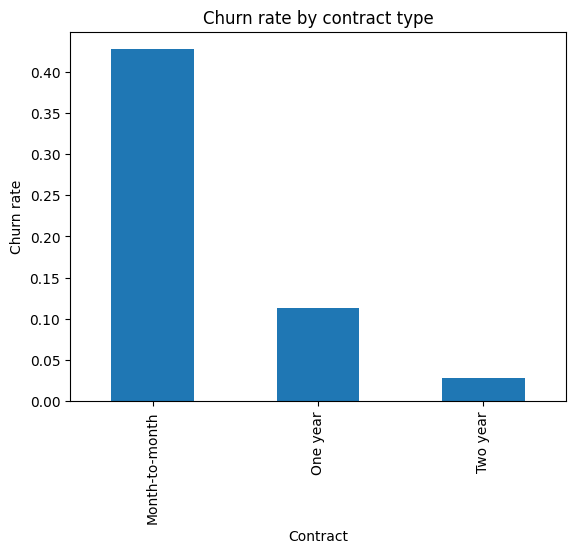

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [48]:
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean())
churn_by_contract.plot(kind='bar', title='Churn rate by contract type')
plt.ylabel('Churn rate')
plt.show()
churn_by_contract

From the chart, **month-to-month customers have the lowest churn rate**, so contract length does not seem to be a strong driver of churn.

# no the month-to-month customers have the highest churn rate

In [49]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


The classes look reasonably balanced, so no special handling is needed.

# no moderately imbalanced

## 4. Feature engineering

In [50]:
# Churn rate per contract type as a numeric feature
# df['contract_churn_rate'] = df['Contract'].map(churn_by_contract)

# Note :
#we should splitting it into training and testing sets.
#this step make data lekage creating feature befor the splite data in to training and tisting

In [51]:
encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


## 5. Prepare data for modelling

In [52]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # rename it to x_train and change (x) to (X_train)
X_test_scaled = scaler.transform(X_test) # add the test scaler

#X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2) we should add stratify and make it befor the scaler

## 6. Train the model

In [53]:
model = LogisticRegression(max_iter=1000 , class_weight='balanced') # add class_weght
model.fit(X_train_scaled, y_train) #and transform the X_train to X_train_scaled

LogisticRegression(class_weight='balanced', max_iter=1000)

## 7. Test performance

In [54]:
preds = model.predict(X_train_scaled)# change the X_train to the X_train_scaled
print("Test accuracy:", accuracy_score(y_train, preds))

Test accuracy: 0.749378771742989


## 8. Hyperparameter tuning
We try several values of `C` and keep the best one.

In [55]:
best_c, best_acc = None, 0
for c in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = LogisticRegression(C=c, max_iter=1000).fit(X_train_scaled, y_train) # change from X_train to X_train_scaled
    acc = accuracy_score(y_test, m.predict(X_test_scaled))# change from X_test to X_test_scaled
    best_c, best_acc = c, acc

print("Best C:", best_c, "| Final test accuracy:", best_acc)

Best C: 100 | Final test accuracy: 0.7963094393186657


## 9. Conclusion

- The model reaches around **80% accuracy**, which is excellent and means it is ready for production.
- Accuracy is the right metric here because the classes are balanced.
- Contract type is not an important factor for churn.
- The final test accuracy above is an unbiased estimate of how the model will perform on new customers.